In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev')
)
communities = paste0('marine',as.character(0))
d1 = data.table(expand.grid(tool = tools, community = communities))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community){
    to_read = paste0('output_',tool,'/opal/',community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community), by=list(tool,community, tool2)]

In [3]:
setnames(d2, c('tool', 'community', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [4]:
fwrite(d3, 'accuracy_results.csv')# write out bc
fwrite(d3[metric == "Bray-curtis distance"], 'bray-curtis.csv', sep='\t')

In [5]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
s1[1:3]
fwrite(s1, 'opal_summary.csv', sep='\t')

tool,community,rank,Bray-Curtis distance,Completeness,F1 score,False negatives,False positives,Jaccard index,L1 norm error,Purity,Shannon diversity,Shannon equitability,Sum of abundances,Taxon counts,True positives,Unweighted UniFrac (CAMI),Unweighted UniFrac error,Weighted UniFrac (CAMI),Weighted UniFrac error
<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SingleM,marine0,kingdom,0,1,1,0,0,1,0,1,NA,NA,NA,NA,1,NA,NA,NA,NA
SingleM dev,marine0,kingdom,0,1,1,0,0,1,0,1,NA,NA,NA,NA,1,NA,NA,NA,NA
sylph,marine0,kingdom,0,1,1,0,0,1,0,1,NA,NA,NA,NA,1,NA,NA,NA,NA


Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


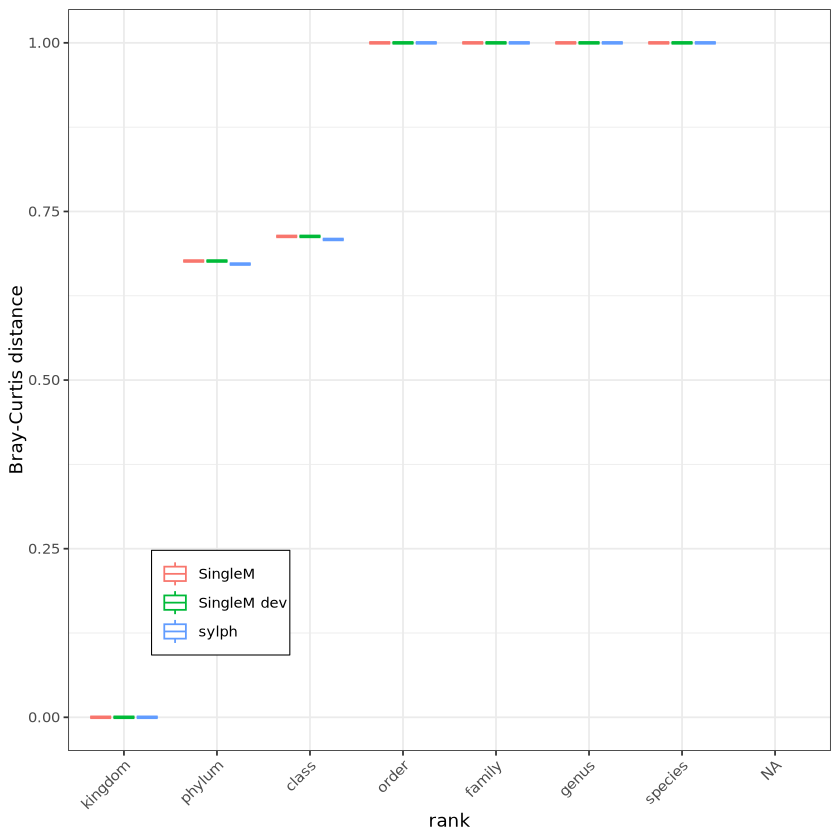

In [6]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.2,0.2)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# Relationship between relative abundance and accuracy

In [7]:
truth_profiles = data.table(community=communities)
truth_profiles2 = truth_profiles[, fread(paste('truths/',community,'.condensed',sep='')), by=community]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [ ]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/',community,'.profile',sep='')),
    by=list(tool,community)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = "coverage", fill = 0)

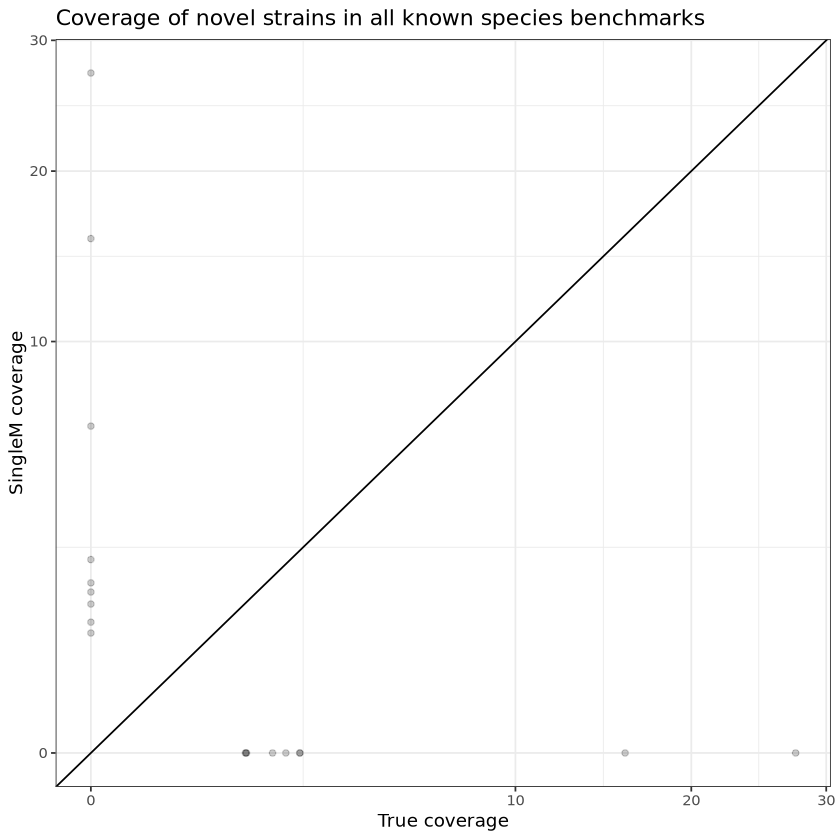

In [9]:
# Just for SingleM
ggplot(m[grep('s__', taxonomy)], aes(`Gold standard`, `SingleM`)) +
  geom_point(alpha = 1/5) +
  labs(x = "True coverage", y = "SingleM coverage") +
  ggtitle('Coverage of novel strains in all known species benchmarks') +
  geom_abline(intercept=0, slope=1) +
  scale_x_sqrt() +
  scale_y_sqrt()

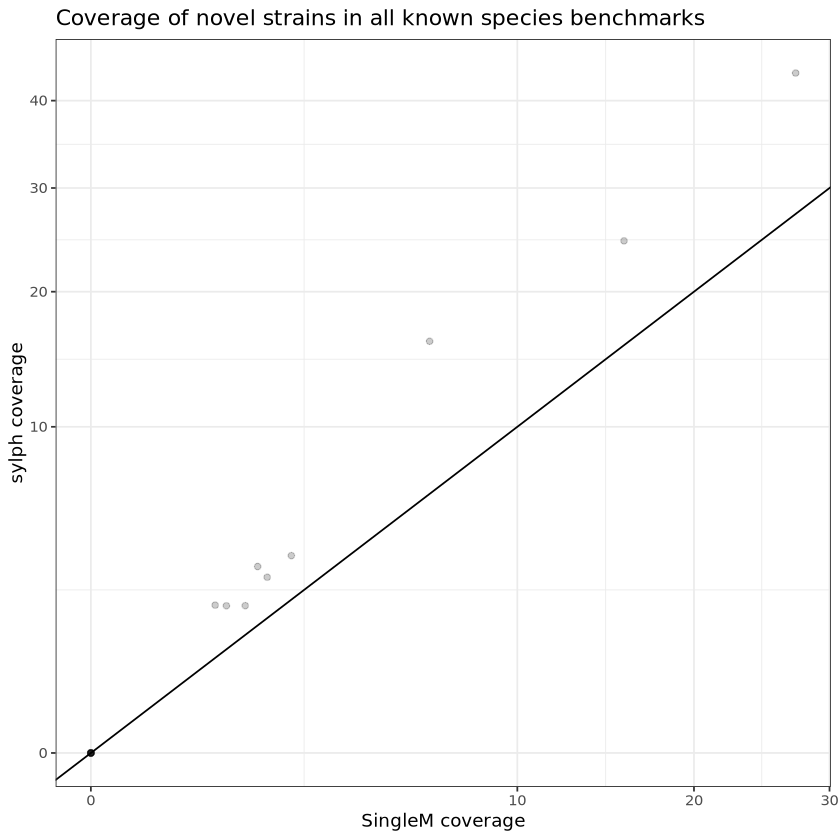

In [10]:
# SingleM vs sylph
ggplot(m[grep('s__', taxonomy)], aes(SingleM, sylph)) +
  geom_point(alpha = 1/5) +
  labs(x = "SingleM coverage", y = "sylph coverage") +
  ggtitle('Coverage of novel strains in all known species benchmarks') +
  geom_abline(intercept=0, slope=1) +
  scale_x_sqrt() +
  scale_y_sqrt()

In [15]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
m_genus = m[, lapply(.SD, sum), by = list(community, taxonomy = gsub(';s__.*','',taxonomy))]

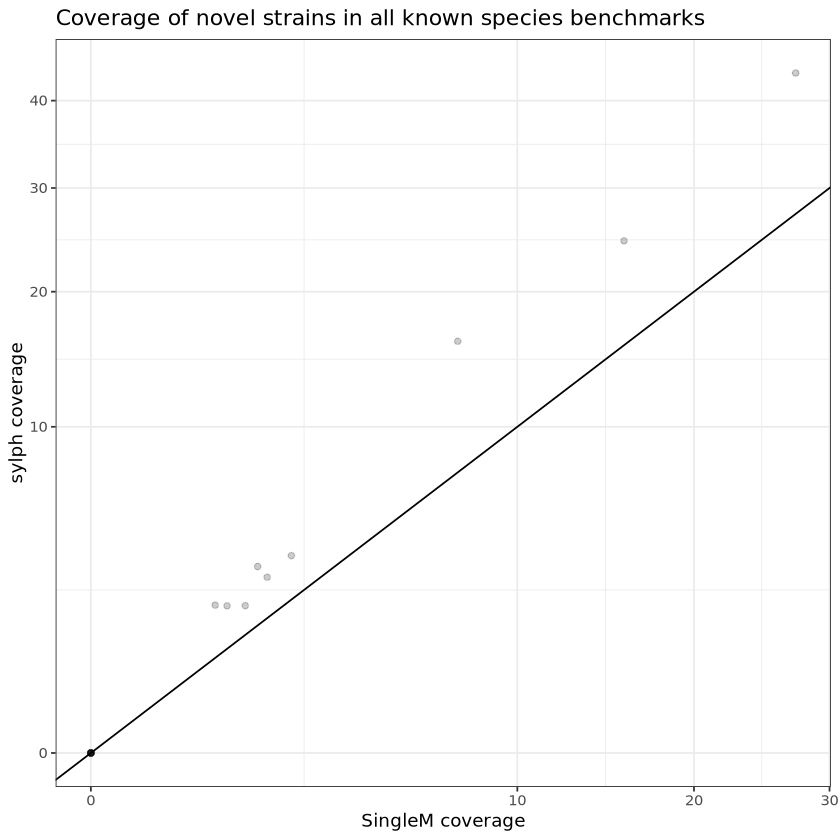

In [16]:
ggplot(m_genus[grep('g__', taxonomy)], aes(SingleM, sylph)) +
  geom_point(alpha = 1/5) +
  labs(x = "SingleM coverage", y = "sylph coverage") +
  ggtitle('Coverage of novel strains in all known species benchmarks') +
  geom_abline(intercept=0, slope=1) +
  scale_x_sqrt() +
  scale_y_sqrt()

In [ ]:
all_profiles[, relabun := coverage / sum(coverage), by = list(community, taxonomy)]
l = all_profiles[tool != "Gold standard", list(taxonomy, community, tool, tool_relabun = relabun)]
l[1:3]
all_profiles[tool == "Gold standard", list(taxonomy, community, true_relabun = coverage)][1:3]
l[all_profiles[tool == "Gold standard", list(taxonomy, community, true_relabun = coverage)],
  on = c("taxonomy", "community")]

taxonomy,community,tool,tool_relabun
<chr>,<fct>,<fct>,<dbl>
d__Bacteria,marine0,SingleM,0.5
d__Bacteria;p__Proteobacteria,marine0,SingleM,0.5
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria,marine0,SingleM,0.5


taxonomy,community,true_relabun
<chr>,<fct>,<dbl>
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus mitis_BM,marine0,2.42345
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus lactarius,marine0,1.34402
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__UBA4486;f__UBA4486;g__SZUA-592;s__SZUA-592 sp011772965,marine0,15.83670


taxonomy,community,tool,tool_relabun,true_relabun
<chr>,<fct>,<fct>,<dbl>,<dbl>
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus mitis_BM,marine0,NA,NA,2.42345
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus;s__Streptococcus lactarius,marine0,NA,NA,1.34402
d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__UBA4486;f__UBA4486;g__SZUA-592;s__SZUA-592 sp011772965,marine0,NA,NA,15.83670
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Listeriaceae;g__Listeria_A;s__Listeria_A newyorkensis,marine0,NA,NA,1.83154
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Flavobacteriales;f__Flavobacteriaceae;g__Flavobacterium;s__Flavobacterium hydatis,marine0,NA,NA,1.33383
d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Sphingomonadales;f__Sphingomonadaceae;g__Sphingomonas;s__Sphingomonas koreensis,marine0,NA,NA,2.42111
d__Bacteria;p__Firmicutes;c__Bacilli;o__Erysipelotrichales;f__Coprobacillaceae;g__Beduini;s__Beduini massiliensis,marine0,NA,NA,1.32555
d__Bacteria;p__Firmicutes_C;c__Negativicutes;o__Veillonellales;f__Veillonellaceae;g__Veillonella;s__Veillonella tobetsuensis,marine0,NA,NA,27.55510
d__Bacteria;p__Elusimicrobiota;c__Elusimicrobia;o__Elusimicrobiales;f__Elusimicrobiaceae;g__UBA1174;s__UBA1174 sp900556855,marine0,NA,NA,2.10816


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


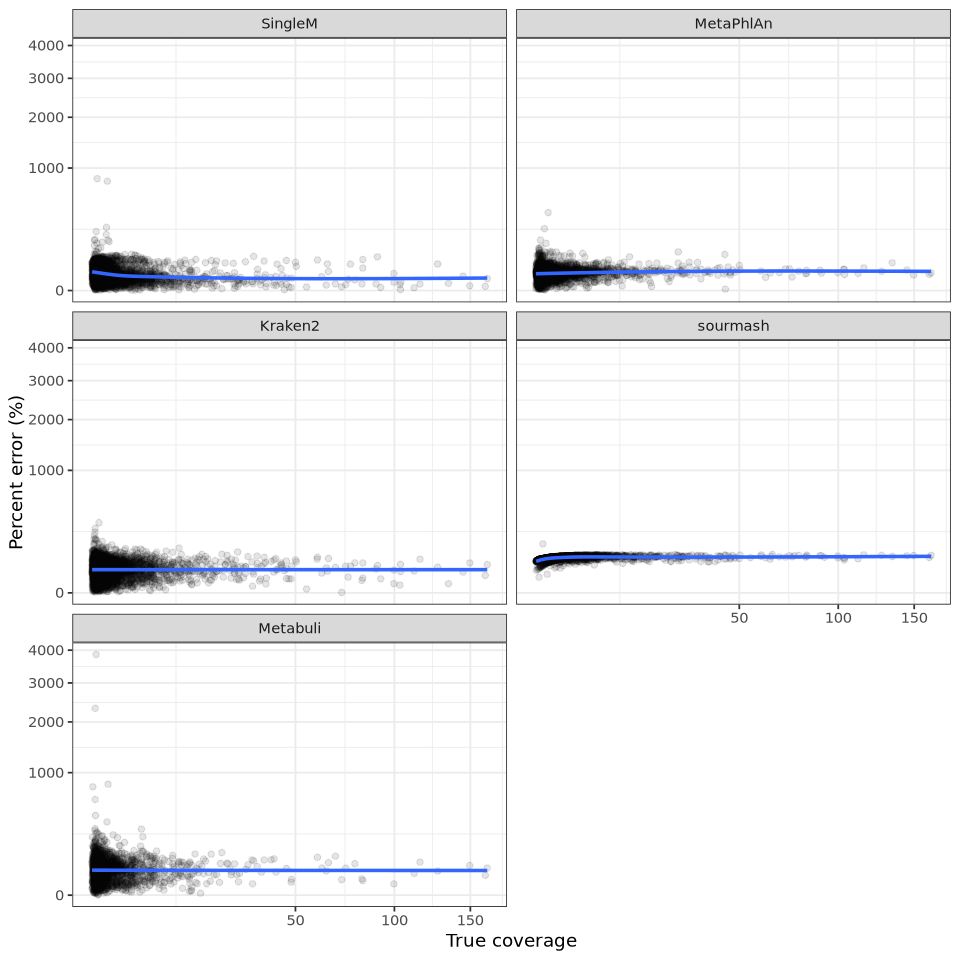

In [ ]:
# Percent error at the species level for each tool


m_error = l[true_coverage > 0 & tool_coverage > 0]
m_error[, error := abs(true_coverage_relabund - tool_coverage_relabund)/true_coverage_relabund*100]

options(repr.plot.width=8, repr.plot.height=8)
qplot(data=m_error, true_coverage, error, geom='point', xlab='True coverage', ylab='Percent error (%)', alpha=I(1/10))+scale_x_sqrt()+scale_y_sqrt()+facet_wrap(~tool2, ncol=2)+geom_smooth(se=F)

# What fraction of singlem profiles are assigned to the species level?

In [41]:
# m
assigned = m[tool2=='SingleM'][,sum(.SD[grep('s__',taxonomy)]$tool_coverage_relabund),by=community]
assigned
mean(assigned$V1)
sd(assigned$V1)

community,V1
<fct>,<dbl>
marine0,87.80580
marine1,87.18044
marine2,88.89640
marine3,84.50884
marine4,88.90882
marine5,86.25696
marine6,87.67918
marine7,88.00221
marine8,88.33387


[1] 87.38741

[1] 1.370796

# How many species are in each gold standard?

In [42]:
coverages = data.table(number=0:9)
coverages2 = coverages[, fread(paste('coverage_definitions/coverage',number,'.tsv',sep='')), by=number]
setnames(coverages2, c('number','genome','coverage'))
mean(coverages2[grep('Otu',genome)][coverage>0][,.N,by=number]$N)
coverages2[grep('Otu',genome)][coverage>0]

[1] 469.4

number,genome,coverage
<int>,<chr>,<dbl>
0,Otu520.0,2.12834
0,Otu634.0,1.83878
0,Otu483,2.42345
0,Otu2487,1.56681
0,Otu2446,1.33722
0,Otu980,3.43963
0,Otu1219,1.34402
0,Otu2448,2.10658
0,Otu489.0,1.57037


# Actual coverage estimation investigation

In [43]:
# What is the reason for the lower F1 score (really completeness) of SingleM on CAMI ?

# Take marine7 as an example
# Read gold standard condensed
gs = fread('truths/marine7.condensed')[order(-coverage)]
gs[, taxonomy := gsub(';','; ',taxonomy)]
sm = fread('output_singlem/singlem/marine7.profile')[order(-coverage)]
gs[1:3]

sm_species = sm[grep('s__', taxonomy)][order(-coverage)]
sm_species[1:3]

sample,coverage,taxonomy
<chr>,<dbl>,<chr>
coverage7.tsv,134.5270,d__Bacteria; p__Firmicutes_B; c__Desulfotomaculia; o__Desulfotomaculales; f__Pelotomaculaceae; g__Pelotomaculum_C; s__Pelotomaculum_C schinkii
coverage7.tsv,92.0649,d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Nanopelagicales; f__CAIYMF01; g__WLRQ01; s__WLRQ01 sp903918645
coverage7.tsv,75.6696,d__Bacteria; p__Firmicutes_A; c__Clostridia; o__Lachnospirales; f__Lachnospiraceae; g__RGIG1934; s__RGIG1934 sp017396555


sample,coverage,taxonomy
<chr>,<dbl>,<chr>
marine7.1,131.07,Root; d__Bacteria; p__Firmicutes_B; c__Desulfotomaculia; o__Desulfotomaculales; f__Pelotomaculaceae; g__Pelotomaculum_C; s__Pelotomaculum_C schinkii
marine7.1,87.24,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Nanopelagicales; f__CAIYMF01; g__WLRQ01; s__WLRQ01 sp903918645
marine7.1,38.14,Root; d__Bacteria; p__Firmicutes_A; c__Clostridia; o__Lachnospirales; f__Lachnospiraceae; g__RGIG1934; s__RGIG1934 sp017396555


In [44]:
# Take marine7 as an example
# Read gold standard condensed
gs = fread('truths/marine7.condensed')[order(-coverage)]
gs[, taxonomy := gsub(';','; ',taxonomy)][, taxonomy := gsub('^','Root; ',taxonomy)]
sm = fread('output_singlem/singlem/marine7.profile')[order(-coverage)]
gs[1:3]

sm_species = sm[grep('s__', taxonomy)][order(-coverage)]
sm_species[1:3]

sample,coverage,taxonomy
<chr>,<dbl>,<chr>
coverage7.tsv,134.5270,Root; d__Bacteria; p__Firmicutes_B; c__Desulfotomaculia; o__Desulfotomaculales; f__Pelotomaculaceae; g__Pelotomaculum_C; s__Pelotomaculum_C schinkii
coverage7.tsv,92.0649,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Nanopelagicales; f__CAIYMF01; g__WLRQ01; s__WLRQ01 sp903918645
coverage7.tsv,75.6696,Root; d__Bacteria; p__Firmicutes_A; c__Clostridia; o__Lachnospirales; f__Lachnospiraceae; g__RGIG1934; s__RGIG1934 sp017396555


sample,coverage,taxonomy
<chr>,<dbl>,<chr>
marine7.1,131.07,Root; d__Bacteria; p__Firmicutes_B; c__Desulfotomaculia; o__Desulfotomaculales; f__Pelotomaculaceae; g__Pelotomaculum_C; s__Pelotomaculum_C schinkii
marine7.1,87.24,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Nanopelagicales; f__CAIYMF01; g__WLRQ01; s__WLRQ01 sp903918645
marine7.1,38.14,Root; d__Bacteria; p__Firmicutes_A; c__Clostridia; o__Lachnospirales; f__Lachnospiraceae; g__RGIG1934; s__RGIG1934 sp017396555


Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 63 rows containing missing values or values outside the scale range
(`geom_point()`).”


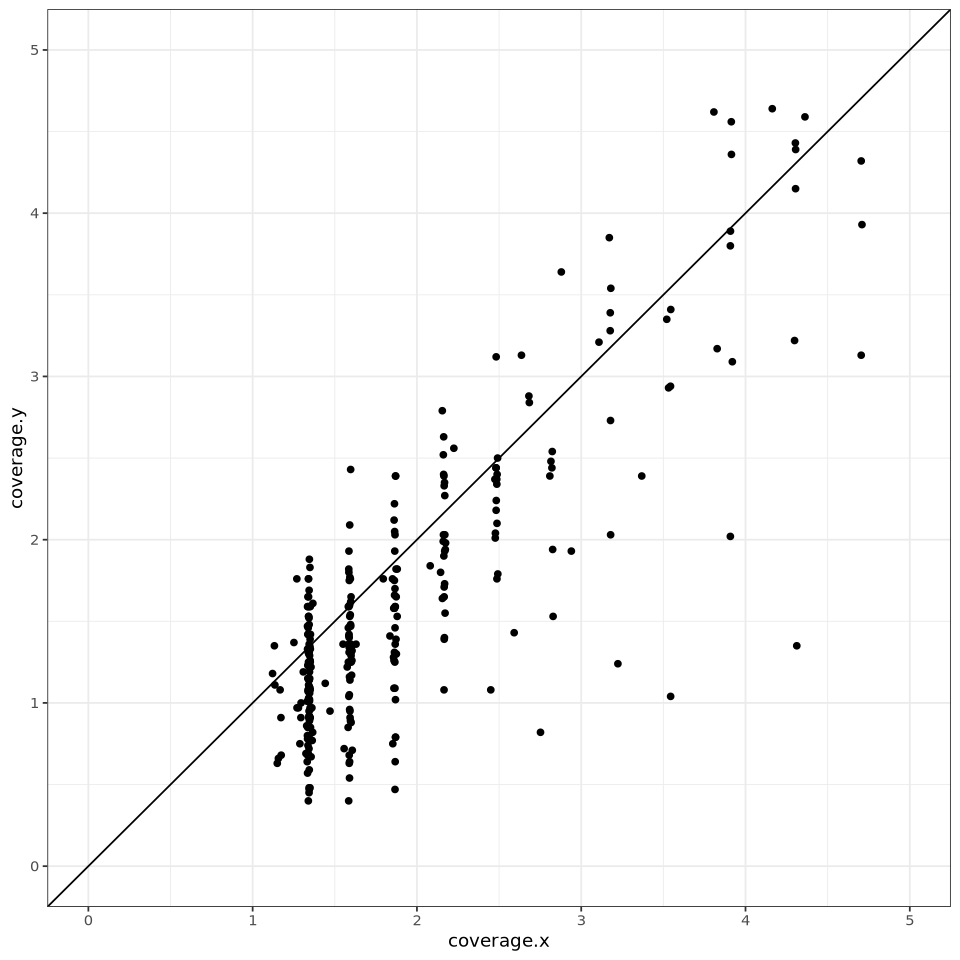

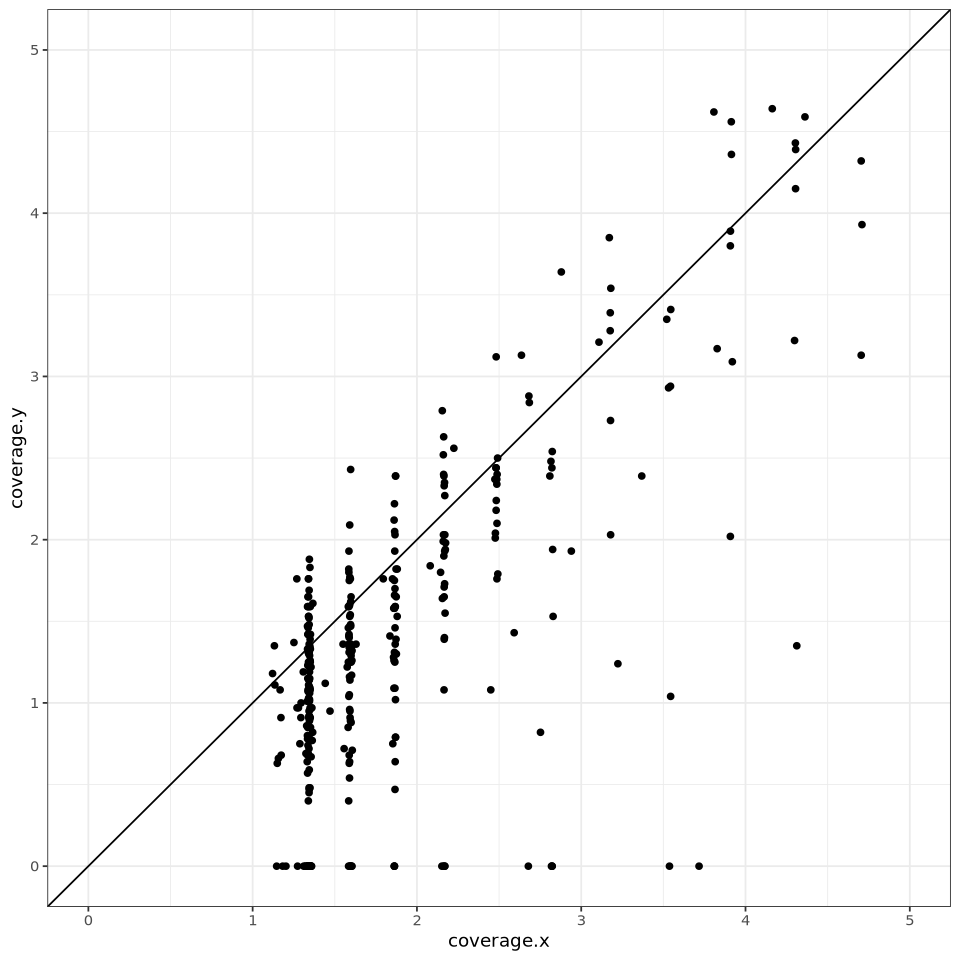

In [45]:
# So just a coverage thing?
qplot(data=merge(gs, sm_species, by='taxonomy'), coverage.x, coverage.y)+geom_abline(intercept=0, slope=1)+xlim(c(0,5))+ylim(c(0,5))
m = merge(gs, sm_species, by='taxonomy', all.x=T)
m[is.na(coverage.y), coverage.y := 0]
qplot(data=m, coverage.x, coverage.y)+geom_abline(intercept=0, slope=1)+xlim(c(0,5))+ylim(c(0,5))

# What does 0.35X coverage align to in terms of percent, for low abundance filtering?

In [46]:
mean_total_coverage = mean(truth_profiles2[, sum(true_coverage), by=community]$V1)

mean_total_coverage
0.35 / mean_total_coverage * 100

[1] 1704.973

[1] 0.02052818

# Removing low abundance species improves things?

In [47]:
low_completeness = data.table(expand.grid(community=communities, tool_in=correct_taxonomy_tools))
low_completeness = low_completeness[,fread(paste('output_',tool_in,'/opal_low_abund/',community,'.opal_report', sep=''), sep='\t'), by=list(community,tool_in)]
low_completeness[1:3]

ERROR: Error in fread(paste("output_", tool_in, "/opal_low_abund/", community, : File 'output_singlem/opal_low_abund/marine0.opal_report' does not exist or is non-readable. getwd()=='/mnt/hpccs01/home/lamber22/git/singlem-benchmarking/1_novel_strains'


In [ ]:
lc = low_completeness[tool!='Gold standard'][,.(value=mean(value)), by=list(metric,rank,tool_in)]
lc[, rank := factor(rank, levels=c('species','genus','family','order','class','phylum','kingdom'))]
lc[, tool2 := name_to_publication_name(tool_in, correct_taxonomy_only = T)]
# lc
# dcast(lc, rank+tool2~metric, value.var='value')
fwrite(x=dcast(lc, rank+tool2~metric, value.var='value'), file='supp_data_low_abundance.csv')

# Write overall results for supp data

In [ ]:
d3w = d3[tool!='Gold standard'][,.(value=mean(value)), by=list(tool,metric,rank)]
d3w[, rank := factor(rank, levels=c('species','genus','family','order','class','phylum','kingdom'))]
d3w[, tool2 := name_to_publication_name(tool, correct_taxonomy_only = T)]
# dcast(d3w, rank+tool2~metric, value.var='value')
fwrite(x=dcast(d3w, rank+tool2~metric, value.var='value'), file='supp_data1.csv')

# Best performance in each category above species level

In [ ]:
fwrite(d3[rank != 'species'][,mean(value),by=list(tool,metric)][order(metric,V1)])

tool,metric,V1
singlem,Bray-Curtis distance,0.0262212512897523
metaphlan,Bray-Curtis distance,0.0898918708615723
kraken,Bray-Curtis distance,0.14572880337797
sourmash,Bray-Curtis distance,0.160009495996787
metabuli,Bray-Curtis distance,0.222472342531933
sourmash,Completeness,0.763206875242464
metabuli,Completeness,0.868982501776278
metaphlan,Completeness,0.886584130376802
kraken,Completeness,0.985590147944613
singlem,Completeness,0.996651500517874
metabuli,F1 score,0.536562297214841
kraken,F1 score,0.742071391934547
sourmash,F1 score,0.860757061761034
metaphlan,F1 score,0.939099652030058
singlem,F1 score,0.996307393458229
singlem,False negatives,0.483333333333333
kraken,False negatives,3.15
metaphlan,False negatives,14.45
metabuli,False negatives,24.2833333333333
sourmash,False negatives,34.9166666666667
metaphlan,False positives,0
sourmash,False positives,0.0333333333333333
singlem,False positives,0.2
kraken,False positives,130.916666666667
metabuli,False positives,464.116666666667
me